In [114]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [115]:
df = pd.read_csv('../data/raw/user_events_ecommerce_product_analytics.csv')

In [116]:
df.head()

,user_id,session_id,event_date,event_time,event_type,product_id,category,price,device,traffic_source,country,city
0,U110476,S2867825,2024-01-13,09:23:00,view,P3286,Men Pants,NaN,Mobile,Referral,USA,San Francisco
1,U100520,S1499914,2024-02-17,07:27:00,purchase,P4257,Casual Wear,2502.94,Web,Email,USA,New York
2,U100106,S3678638,2024-12-23,14:25:00,add_to_cart,P3547,Women Pants,4815.02,Web,Organic,UK,Manchester
3,U101519,S7374122,2024-02-19,12:15:00,view,P1711,Formal Wear,NaN,Mobile,Referral,UK,Manchester
4,U101291,S5918715,2024-11-17,21:06:00,visit,P2139,Men Pants,NaN,Mobile,Email,UK,London


In [117]:
df.dtypes

user_id            object
session_id         object
event_date         object
event_time         object
event_type         object
product_id         object
category           object
price             float64
device             object
traffic_source     object
country            object
city               object
dtype: object

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320000 entries, 0 to 319999
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         320000 non-null  object 
 1   session_id      320000 non-null  object 
 2   event_date      320000 non-null  object 
 3   event_time      320000 non-null  object 
 4   event_type      320000 non-null  object 
 5   product_id      320000 non-null  object 
 6   category        320000 non-null  object 
 7   price           121820 non-null  float64
 8   device          320000 non-null  object 
 9   traffic_source  320000 non-null  object 
 10  country         320000 non-null  object 
 11  city            320000 non-null  object 
dtypes: float64(1), object(11)
memory usage: 29.3+ MB


In [119]:
df.isna().sum()

user_id                0
session_id             0
event_date             0
event_time             0
event_type             0
product_id             0
category               0
price             198180
device                 0
traffic_source         0
country                0
city                   0
dtype: int64

In [120]:
df.duplicated().sum()

np.int64(0)

In [121]:
df[df['event_type'].isin(['view', 'visit'])]['price'].isna().sum() # -> NaN значения , только при view и vist 

np.int64(198180)

In [122]:
df['event_date'] = df['event_date'] +" " +df['event_time'] 

In [123]:
df['event_date'] = pd.to_datetime(df['event_date'])


In [124]:
df.head(5)

,user_id,session_id,event_date,event_time,event_type,product_id,category,price,device,traffic_source,country,city
0,U110476,S2867825,2024-01-13 09:23:00,09:23:00,view,P3286,Men Pants,NaN,Mobile,Referral,USA,San Francisco
1,U100520,S1499914,2024-02-17 07:27:00,07:27:00,purchase,P4257,Casual Wear,2502.94,Web,Email,USA,New York
2,U100106,S3678638,2024-12-23 14:25:00,14:25:00,add_to_cart,P3547,Women Pants,4815.02,Web,Organic,UK,Manchester
3,U101519,S7374122,2024-02-19 12:15:00,12:15:00,view,P1711,Formal Wear,NaN,Mobile,Referral,UK,Manchester
4,U101291,S5918715,2024-11-17 21:06:00,21:06:00,visit,P2139,Men Pants,NaN,Mobile,Email,UK,London


In [125]:
df.dtypes

user_id                   object
session_id                object
event_date        datetime64[ns]
event_time                object
event_type                object
product_id                object
category                  object
price                    float64
device                    object
traffic_source            object
country                   object
city                      object
dtype: object

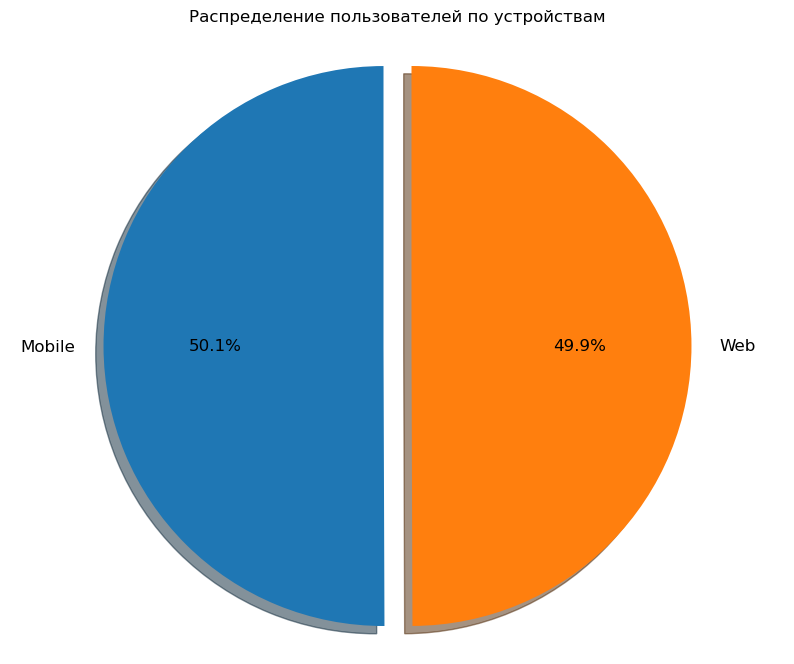

In [126]:
device_counts=df.groupby('device' , as_index=False)['user_id'].count()\
    .rename(columns = {'user_id':'count'})
device_counts = device_counts.sort_values('count', ascending=False)

plt.figure(figsize=(10, 8))

plt.pie(device_counts['count'], 
        labels=device_counts['device'],
        autopct='%1.1f%%',      
        startangle=90,          
        shadow=True,
        explode=[0.05] * len(device_counts),
        textprops={'fontsize': 12})

plt.title('Распределение пользователей по устройствам', fontsize=12, pad=12)
plt.axis('equal') 
plt.show()

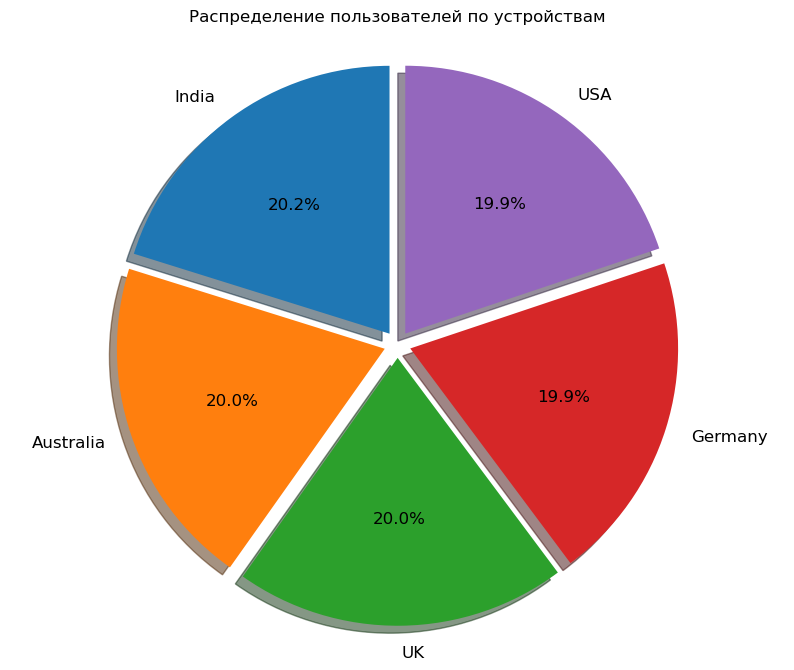

In [127]:
county_counts = df.groupby('country' , as_index=False)['user_id'].count()\
    .rename(columns = {'user_id':'count'})
county_counts = county_counts.sort_values('count', ascending=False)

plt.figure(figsize=(10, 8))

plt.pie(county_counts['count'], 
        labels=county_counts['country'],
        autopct='%1.1f%%',      
        startangle=90,          
        shadow=True,
        explode=[0.05] * len(county_counts),
        textprops={'fontsize': 12})

plt.title('Распределение пользователей по устройствам', fontsize=12, pad=12)
plt.axis('equal') 
plt.show()

In [128]:
df.head(5)

,user_id,session_id,event_date,event_time,event_type,product_id,category,price,device,traffic_source,country,city
0,U110476,S2867825,2024-01-13 09:23:00,09:23:00,view,P3286,Men Pants,NaN,Mobile,Referral,USA,San Francisco
1,U100520,S1499914,2024-02-17 07:27:00,07:27:00,purchase,P4257,Casual Wear,2502.94,Web,Email,USA,New York
2,U100106,S3678638,2024-12-23 14:25:00,14:25:00,add_to_cart,P3547,Women Pants,4815.02,Web,Organic,UK,Manchester
3,U101519,S7374122,2024-02-19 12:15:00,12:15:00,view,P1711,Formal Wear,NaN,Mobile,Referral,UK,Manchester
4,U101291,S5918715,2024-11-17 21:06:00,21:06:00,visit,P2139,Men Pants,NaN,Mobile,Email,UK,London


In [129]:
df.groupby('city')['user_id'].count()

city
Austin           15947
Bangalore        12973
Berlin           31920
Chicago          15889
Delhi            12964
Hyderabad        12929
London           32043
Manchester       31999
Melbourne        31985
Mumbai           12741
Munich           31892
New York         15869
Pune             12956
San Francisco    15826
Sydney           32067
Name: user_id, dtype: int64

In [130]:
df['session_id'].nunique()

314284

In [131]:
df['session_id'].nunique()/df.shape[0]

0.9821375

In [132]:
df[df['session_id'].duplicated(keep=False)].sort_values(by = 'session_id') # -> У разных юзеров одинковый session_id , создадим уникальный sesion_id

,user_id,session_id,event_date,event_time,event_type,product_id,category,price,device,traffic_source,country,city
114059,U106590,S1000882,2024-09-09 19:57:00,19:57:00,visit,P5267,Men Pants,NaN,Web,Referral,Germany,Munich
176424,U105068,S1000882,2024-02-07 01:43:00,01:43:00,visit,P9676,Men Pants,NaN,Web,Referral,UK,London
76698,U106439,S1001780,2024-12-01 10:05:00,10:05:00,add_to_cart,P7827,Casual Wear,4922.16,Mobile,Organic,Germany,Munich
313817,U111320,S1001780,2024-11-09 22:39:00,22:39:00,visit,P3631,Jeans,NaN,Mobile,Referral,Germany,Munich
303049,U106886,S1003208,2024-10-07 09:38:00,09:38:00,view,P3390,Men Pants,NaN,Web,Email,India,Mumbai
...,...,...,...,...,...,...,...,...,...,...,...,...
214685,U102595,S9993118,2024-01-15 10:47:00,10:47:00,visit,P7105,Women Pants,NaN,Mobile,Ads,USA,Austin
255733,U108088,S9997406,2024-01-20 16:50:00,16:50:00,view,P8318,Men Pants,NaN,Web,Email,UK,Manchester
278169,U108798,S9997406,2024-04-28 20:47:00,20:47:00,visit,P6143,Formal Wear,NaN,Web,Referral,India,Bangalore
210603,U106582,S9998943,2024-05-16 18:11:00,18:11:00,checkout,P6675,Formal Wear,3643.32,Mobile,Email,UK,London


In [133]:
df_clean = df.drop_duplicates(subset='session_id')

In [134]:
df_clean.to_csv('../data/processed/clean_data.csv')